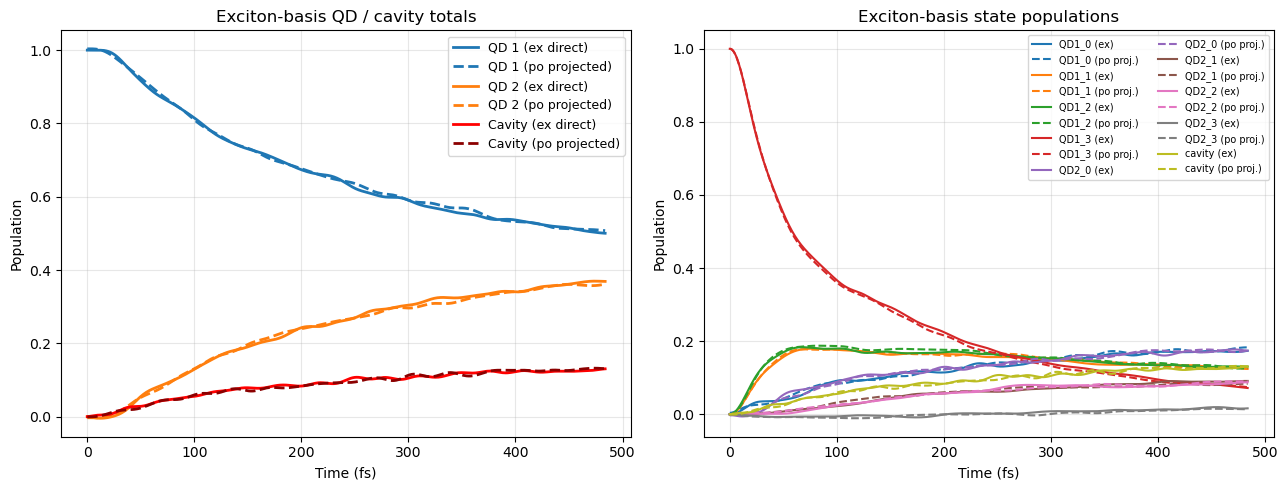

Exciton run (direct exciton basis):
  QD 1 max: 1
  QD 2 max: 0.369789
  Cavity max: 0.130491
  Mean total population: 1

Polariton run projected to exciton basis (full rho):
  QD 1 max: 1.00366
  QD 2 max: 0.361564
  Cavity max: 0.1323
  Mean total population: 1

Projection checks:
  max |ex pop.out - diag(rho_ex)|: 0.000e+00
  max |full-rho - pop-only projection|: 2.075e-02
  max |ex direct - po projected|: 1.545e-02


In [1]:
#!/usr/bin/env python3
"""
Compare exciton-basis populations from the direct ex run with exciton-basis
populations projected from the corresponding polariton (po) run.

State ordering:
- States 0-3: QD 1 exciton states
- States 4-7: QD 2 exciton states
- State 8: cavity photon state

The ex run is propagated in the exciton basis (`pop.out`, `rho.npz`).
The po run is propagated in the polariton basis; project with the full
density matrix (including coherences):

    rho_ex(t) = U rho_pol(t) U^H
"""

import os
import numpy as np
import matplotlib.pyplot as plt

PO_DIR = "../TEST_2QD_po_in_lvc_40meV"

autos = 2.4188843265857e-17
n_qd = 2
nstate_per_qd = 4
n_cavity = 1
n_qd_states = n_qd * nstate_per_qd
n_states_expected = n_qd_states + n_cavity


def qd_cavity_totals(pop):
    """Sum each QD's exciton subspace and return cavity population."""
    qd_total = np.zeros((pop.shape[0], n_qd))
    for qd in range(n_qd):
        start = qd * nstate_per_qd
        end = (qd + 1) * nstate_per_qd
        qd_total[:, qd] = pop[:, start:end].sum(axis=1)
    cavity = pop[:, n_qd_states]
    return qd_total, cavity


def project_rho_to_exciton(rho_pol, U):
    """Unitary projection rho_ex = U rho_pol U^H for all time slices."""
    return np.einsum("ia,tab,jb->tij", U, rho_pol, np.conj(U))


# --- exciton-basis run (this directory) ---
data_ex = np.loadtxt("pop.out")
time_ex = data_ex[:, 0] * autos * 1e15
pop_ex = data_ex[:, 1:]

rhoz_ex = np.load("rho.npz")
rho_ex = rhoz_ex["rho_re"] + 1j * rhoz_ex["rho_im"]
pop_ex_from_rho = np.real(np.diagonal(rho_ex, axis1=1, axis2=2))

if pop_ex.shape[1] != n_states_expected:
    raise ValueError(f"Expected {n_states_expected} states in ex pop.out, found {pop_ex.shape[1]}")

# --- polariton-basis run (corresponding po directory) ---
po_pop_path = os.path.join(PO_DIR, "pop.out")
po_rho_path = os.path.join(PO_DIR, "rho.npz")
po_transform_path = os.path.join(PO_DIR, "polariton_transform_AU.npz")

if not os.path.exists(po_pop_path):
    raise FileNotFoundError(f"Missing {po_pop_path}")
if not os.path.exists(po_rho_path):
    raise FileNotFoundError(
        f"Missing {po_rho_path}. Re-run the po job with -rho to enable full projection."
    )
if not os.path.exists(po_transform_path):
    raise FileNotFoundError(f"Missing {po_transform_path}")

data_po = np.loadtxt(po_pop_path)
time_po = data_po[:, 0] * autos * 1e15
pop_pol = data_po[:, 1:]

transform = np.load(po_transform_path, allow_pickle=True)
U = transform["exciton_to_polariton_U"]
state_labels = transform["exciton_state_labels"] if "exciton_state_labels" in transform.files else None

if U.shape != (n_states_expected, n_states_expected):
    raise ValueError(f"Unexpected U shape {U.shape}")

rhoz_po = np.load(po_rho_path)
rho_pol = rhoz_po["rho_re"] + 1j * rhoz_po["rho_im"]
rho_ex_from_po = project_rho_to_exciton(rho_pol, U)
pop_ex_from_po = np.real(np.diagonal(rho_ex_from_po, axis1=1, axis2=2))
pop_ex_from_po_poponly = pop_pol @ (np.abs(U) ** 2).T

qd_total_ex, cavity_ex = qd_cavity_totals(pop_ex)
qd_total_po, cavity_po = qd_cavity_totals(pop_ex_from_po)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for qd in range(n_qd):
    ax.plot(time_ex, qd_total_ex[:, qd], linewidth=2, color=f"C{qd}", label=f"QD {qd + 1} (ex direct)")
    ax.plot(time_po, qd_total_po[:, qd], "--", linewidth=2, color=f"C{qd}", label=f"QD {qd + 1} (po projected)")
ax.plot(time_ex, cavity_ex, linewidth=2, color="red", label="Cavity (ex direct)")
ax.plot(time_po, cavity_po, "--", linewidth=2, color="darkred", label="Cavity (po projected)")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Population")
ax.set_title("Exciton-basis QD / cavity totals")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for state in range(n_states_expected):
    label = str(state_labels[state]) if state_labels is not None else f"state {state}"
    ax.plot(time_ex, pop_ex[:, state], linewidth=1.5, color=f"C{state % 10}", label=f"{label} (ex)")
    ax.plot(time_po, pop_ex_from_po[:, state], "--", linewidth=1.5, color=f"C{state % 10}", label=f"{label} (po proj.)")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Population")
ax.set_title("Exciton-basis state populations")
ax.legend(ncol=2, fontsize=7)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Exciton run (direct exciton basis):")
for qd in range(n_qd):
    print(f"  QD {qd + 1} max: {qd_total_ex[:, qd].max():.6g}")
print(f"  Cavity max: {cavity_ex.max():.6g}")
print(f"  Mean total population: {(qd_total_ex.sum(axis=1) + cavity_ex).mean():.6g}")

print("\nPolariton run projected to exciton basis (full rho):")
for qd in range(n_qd):
    print(f"  QD {qd + 1} max: {qd_total_po[:, qd].max():.6g}")
print(f"  Cavity max: {cavity_po.max():.6g}")
print(f"  Mean total population: {(qd_total_po.sum(axis=1) + cavity_po).mean():.6g}")

print("\nProjection checks:")
print(f"  max |ex pop.out - diag(rho_ex)|: {np.max(np.abs(pop_ex - pop_ex_from_rho)):.3e}")
print(f"  max |full-rho - pop-only projection|: {np.max(np.abs(pop_ex_from_po - pop_ex_from_po_poponly)):.3e}")
print(f"  max |ex direct - po projected|: {np.max(np.abs(pop_ex - pop_ex_from_po)):.3e}")


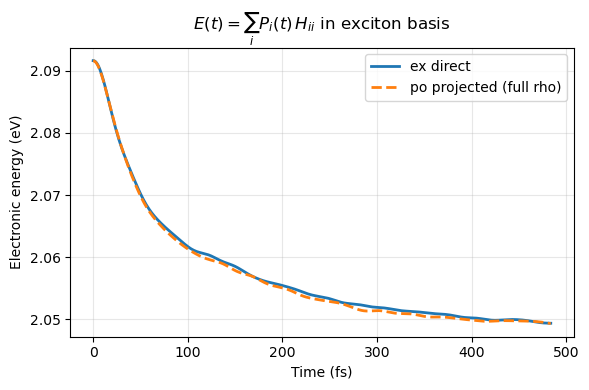

Exciton run (direct):
  E(0)  = 2.091585 eV
  E(end)= 2.049395 eV
  ΔE    = -42.189 meV

Polariton run projected to exciton basis (full rho):
  E(0)  = 2.091572 eV
  E(end)= 2.049340 eV
  ΔE    = -42.231 meV


In [2]:
#!/usr/bin/env python3
"""
Electronic energy relaxation from exciton-basis populations.

Uses only the diagonal of H:
  E(t) = sum_i P_i(t) * H_ii
"""

import os
import numpy as np
import matplotlib.pyplot as plt

PO_DIR = "../TEST_2QD_po_in_lvc_40meV"
autos = 2.4188843265857e-17
autoev = 27.2114079527

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15
populations = data[:, 1:]
params = np.load("lvc_params_AU.npz")
ham_sys_AU = np.real(params["ham_sys_AU"])
E_diag_eV = np.diag(ham_sys_AU) * autoev
E_t_eV = populations @ E_diag_eV
dE_meV = (E_t_eV - E_t_eV[0]) * 1e3

data_po = np.loadtxt(os.path.join(PO_DIR, "pop.out"))
time_po = data_po[:, 0] * autos * 1e15
transform = np.load(os.path.join(PO_DIR, "polariton_transform_AU.npz"), allow_pickle=True)
ham_exciton_AU = np.real(transform["ham_sys_exciton_AU"])
E_diag_eV_po = np.diag(ham_exciton_AU) * autoev

rhoz_po = np.load(os.path.join(PO_DIR, "rho.npz"))
U = transform["exciton_to_polariton_U"]
rho_pol = rhoz_po["rho_re"] + 1j * rhoz_po["rho_im"]
rho_ex_from_po = np.einsum("ia,tab,jb->tij", U, rho_pol, np.conj(U))
pop_ex_from_po = np.real(np.diagonal(rho_ex_from_po, axis1=1, axis2=2))

E_t_eV_po = pop_ex_from_po @ E_diag_eV_po
dE_meV_po = (E_t_eV_po - E_t_eV_po[0]) * 1e3

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(time, E_t_eV, linewidth=2, color="C0", label="ex direct")
ax.plot(time_po, E_t_eV_po, linewidth=2, color="C1", linestyle="--", label="po projected (full rho)")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Electronic energy (eV)")
ax.set_title(r"$E(t)=\sum_i P_i(t)\,H_{ii}$ in exciton basis")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Exciton run (direct):")
print(f"  E(0)  = {E_t_eV[0]:.6f} eV")
print(f"  E(end)= {E_t_eV[-1]:.6f} eV")
print(f"  ΔE    = {dE_meV[-1]:.3f} meV")

print("\nPolariton run projected to exciton basis (full rho):")
print(f"  E(0)  = {E_t_eV_po[0]:.6f} eV")
print(f"  E(end)= {E_t_eV_po[-1]:.6f} eV")
print(f"  ΔE    = {dE_meV_po[-1]:.3f} meV")

